# Escenario NSE2 Lunar Communication

Esta notebook replica el flujo de analisis de `four_planes_polar`, pero corre el escenario lunar para:

- dos topologias alternativas: `topology_1.json` y `topology_2.json`
- tres conjuntos de pares de trafico: `mission_core`, `cross_support` e `infra_ops`

Tambien incluye un helper para inspeccionar en detalle cualquier combinacion topologia + conjunto de pares.


In [16]:
from pathlib import Path
import sys
from collections import OrderedDict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if (candidate / "modules").is_dir() and (candidate / "pipelines").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("No se pudo ubicar el repo root desde el cwd actual")

SCENARIO_DIR = CURRENT_DIR
if not (SCENARIO_DIR / "contact_plan.json").exists():
    scenario_candidate = REPO_ROOT / "scenarios" / "nse2_lunar_communication"
    if not scenario_candidate.exists():
        raise RuntimeError("No se pudo ubicar el directorio del escenario nse2_lunar_communication")
    SCENARIO_DIR = scenario_candidate

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType, KeyType
from pipelines.routing import CGRYenRouting
from pipelines.route_activation import RouteActivationPlanner
from pipelines.simulation import (
    AnnotationBatchResult,
    RoutingBatchResult,
    SecurityBatchResult,
    SimulationPipeline,
    SimulationResult,
)
from models.plot_utils import set_plot_theme

set_plot_theme()
sns.set_theme(style="whitegrid")

NODE_LABELS = {
    10: "b1cc",
    11: "base1",
    20: "r1cc",
    21: "rover1",
    30: "u1cc",
    31: "user1",
    100: "rcc1",
    110: "gs1",
    120: "relay1",
    200: "rcc2",
    210: "gs2",
    220: "lgw",
    221: "relay2",
}

PAIR_SET_ORDER = ["mission_core", "cross_support", "infra_ops"]
TOPOLOGY_ORDER = ["topology_1", "topology_2"]
MODEL_ORDER = [model.name for model in SecurityModelType]

PAIR_SETS = OrderedDict(
    mission_core=(
        (10, 11), (11, 10),
        (20, 21), (21, 20),
        (30, 31), (31, 30),
        (11, 21), (21, 11),
        (31, 11), (11, 31),
        (31, 21), (21, 31),
    ),
    cross_support=(
        (10, 21), (21, 10),
        (20, 11), (11, 20),
        (10, 31), (31, 10),
        (30, 11), (11, 30),
        (30, 21), (21, 30),
    ),
    infra_ops=(
        (100, 110), (110, 100),
        (100, 120), (120, 100),
        (200, 210), (210, 200),
        (200, 220), (220, 200),
        (200, 221), (221, 200),
    ),
)

TOPOLOGY_FILES = OrderedDict(
    topology_1=SCENARIO_DIR / "topology_1.json",
    topology_2=SCENARIO_DIR / "topology_2.json",
)

SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}
MODEL_PALETTE = {model.name: color for model, color in SERIES_COLORS.items()}
MAX_ROUTES = 3


def format_pair(pair):
    return f"{pair[0]}->{pair[1]}"


def describe_pair(pair):
    src, dst = pair
    return f"{NODE_LABELS[src]} ({src}) -> {NODE_LABELS[dst]} ({dst})"


def pct_of_max(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value == 0:
        return series * 0
    return 100.0 * series / max_value


def apply_percent_yaxis(grid_or_axes):
    if hasattr(grid_or_axes, "axes"):
        axes = grid_or_axes.axes.flat
    elif hasattr(grid_or_axes, "flat"):
        axes = grid_or_axes.flat
    elif isinstance(grid_or_axes, (list, tuple)):
        axes = grid_or_axes
    else:
        axes = [grid_or_axes]
    for ax in axes:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))


def apply_percent_xaxis(grid_or_axes):
    if hasattr(grid_or_axes, "axes"):
        axes = grid_or_axes.axes.flat
    elif hasattr(grid_or_axes, "flat"):
        axes = grid_or_axes.flat
    elif isinstance(grid_or_axes, (list, tuple)):
        axes = grid_or_axes
    else:
        axes = [grid_or_axes]
    for ax in axes:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))


def filter_simulation_result(result: SimulationResult, selected_pairs):
    selected_pairs = tuple(selected_pairs)
    missing_pairs = [pair for pair in selected_pairs if pair not in result.routing.routes_by_pair]
    if missing_pairs:
        raise ValueError(f"Pairs not present in result: {missing_pairs}")

    routing = RoutingBatchResult(
        topology=result.routing.topology,
        contact_plan_size=result.routing.contact_plan_size,
        pairs=selected_pairs,
        routes_by_pair={pair: result.routing.routes_by_pair[pair] for pair in selected_pairs},
    )
    annotation = AnnotationBatchResult(
        topology=result.annotation.topology,
        contact_plan_size=result.annotation.contact_plan_size,
        pairs=selected_pairs,
        routes_by_pair={pair: result.annotation.routes_by_pair[pair] for pair in selected_pairs},
        annotated_routes_by_pair={pair: result.annotation.annotated_routes_by_pair[pair] for pair in selected_pairs},
    )
    security = SecurityBatchResult(
        pairs=selected_pairs,
        symmetric_keys=result.security.symmetric_keys,
        plans_by_model={
            model: {pair: plans_by_pair[pair] for pair in selected_pairs}
            for model, plans_by_pair in result.security.plans_by_model.items()
        },
    )
    return SimulationResult(
        topology=result.topology,
        contact_plan_size=result.contact_plan_size,
        routing=routing,
        annotation=annotation,
        security=security,
    )


pipeline = SimulationPipeline()
base_results = {
    topology_name: pipeline.run(
        cp_path=str(SCENARIO_DIR / "contact_plan.json"),
        topology_path=str(topology_path),
        security_models=tuple(SecurityModelType),
        curr_time=0,
        routing_algorithm=CGRYenRouting(max_routes=MAX_ROUTES),
        num_routes=MAX_ROUTES,
        symmetric_keys=True,
    )
    for topology_name, topology_path in TOPOLOGY_FILES.items()
}

experiment_results = OrderedDict()
experiment_meta = {}
for topology_name, base_result in base_results.items():
    for pair_set_name, pairs in PAIR_SETS.items():
        config_name = f"{topology_name}__{pair_set_name}"
        filtered_result = filter_simulation_result(base_result, pairs)
        experiment_results[config_name] = filtered_result
        experiment_meta[config_name] = {
            "topology": topology_name,
            "pair_set": pair_set_name,
            "pair_count": len(pairs),
        }

print(f"Experimentos cargados: {len(experiment_results)}")
list(experiment_results)


Experimentos cargados: 6


['topology_1__mission_core',
 'topology_1__cross_support',
 'topology_1__infra_ops',
 'topology_2__mission_core',
 'topology_2__cross_support',
 'topology_2__infra_ops']

In [17]:
pair_rows = []
for pair_set_name, pairs in PAIR_SETS.items():
    for pair in pairs:
        pair_rows.append(
            {
                "pair_set": pair_set_name,
                "pair": format_pair(pair),
                "description": describe_pair(pair),
            }
        )

pair_df = pd.DataFrame(pair_rows)
display(pair_df.groupby("pair_set")["pair"].count().rename("pairs").to_frame())
display(pair_df)


,pairs
pair_set,
cross_support,10
infra_ops,10
mission_core,12


,pair_set,pair,description
0,mission_core,10->11,b1cc (10) -> base1 (11)
1,mission_core,11->10,base1 (11) -> b1cc (10)
2,mission_core,20->21,r1cc (20) -> rover1 (21)
3,mission_core,21->20,rover1 (21) -> r1cc (20)
4,mission_core,30->31,u1cc (30) -> user1 (31)
5,mission_core,31->30,user1 (31) -> u1cc (30)
6,mission_core,11->21,base1 (11) -> rover1 (21)
7,mission_core,21->11,rover1 (21) -> base1 (11)
8,mission_core,31->11,user1 (31) -> base1 (11)
9,mission_core,11->31,base1 (11) -> user1 (31)


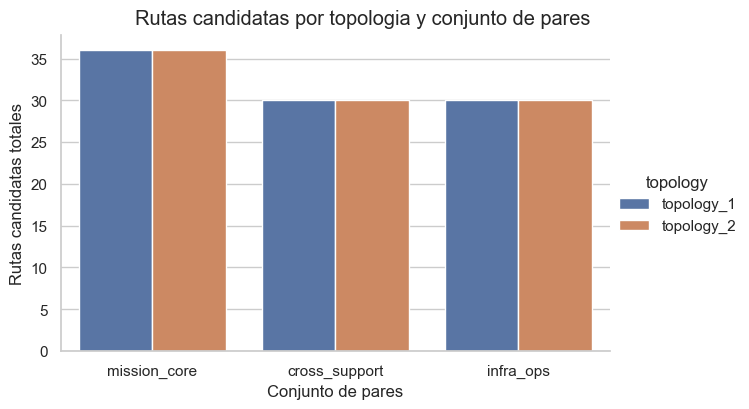

In [46]:
planner = RouteActivationPlanner()

summary_rows = []
key_rows = []
for config_name, sim_result in experiment_results.items():
    topology_name = experiment_meta[config_name]["topology"]
    pair_set_name = experiment_meta[config_name]["pair_set"]
    route_count = sum(len(routes) for routes in sim_result.routing.routes_by_pair.values())
    reachable_pairs = sum(1 for routes in sim_result.routing.routes_by_pair.values() if routes)

    summary_rows.append(
        {
            "config": config_name,
            "topology": topology_name,
            "pair_set": pair_set_name,
            "pairs": len(sim_result.security.pairs),
            "reachable_pairs": reachable_pairs,
            "total_routes": route_count,
            "avg_routes_per_pair": route_count / len(sim_result.security.pairs),
        }
    )

    for model in SecurityModelType:
        planning = planner.build_for_model(sim_result.security, model=model)
        key_scopes = planning.key_scopes
        counts = {
            "N-N": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_NODE),
            "N-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_GROUP),
            "G-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.GROUP_TO_GROUP),
        }
        counts["Total"] = len(key_scopes)
        for key_type_label, count in counts.items():
            key_rows.append(
                {
                    "config": config_name,
                    "topology": topology_name,
                    "pair_set": pair_set_name,
                    "model": model.name,
                    "key_type": key_type_label,
                    "count": count,
                }
            )

summary_df = pd.DataFrame(summary_rows)
key_summary_df = pd.DataFrame(key_rows)

summary_df["total_routes_pct"] = pct_of_max(summary_df["total_routes"])
# display(summary_df)

g = sns.catplot(
    data=summary_df,
    kind="bar",
    x="pair_set",
    y="total_routes",
    hue="topology",
    height=4,
    aspect=1.6,
)
g.set_axis_labels("Conjunto de pares", "Rutas candidatas totales")
g.figure.suptitle("Rutas candidatas por topologia y conjunto de pares", y=1.02)
plt.show()


## Complejidad de rutas

Los siguientes graficos resumen la complejidad estructural de las rutas candidatas para cada combinacion `topology + pair_set`:

- cantidad de hops por ruta
- cantidad de cruces de frontera por ruta


In [19]:
route_rows = []
for config_name, sim_result in experiment_results.items():
    topology_name = experiment_meta[config_name]["topology"]
    pair_set_name = experiment_meta[config_name]["pair_set"]
    case_name = topology_name + "\n" + pair_set_name

    for pair in sim_result.routing.pairs:
        raw_routes = sim_result.routing.routes_by_pair[pair]
        annotated_routes = sim_result.annotation.annotated_routes_by_pair[pair]
        for route_index, (raw_route, annotated_route) in enumerate(zip(raw_routes, annotated_routes), start=1):
            hops_count = len(raw_route.get_hops())
            boundary_crossings_count = len(annotated_route.boundary_crossings)
            route_rows.append(
                {
                    "config": config_name,
                    "topology": topology_name,
                    "pair_set": pair_set_name,
                    "case": case_name,
                    "pair": format_pair(pair),
                    "route_id": f"{format_pair(pair)}:route-{route_index}",
                    "hops_count": hops_count,
                    "boundary_crossings_count": boundary_crossings_count,
                }
            )

route_stats_df = pd.DataFrame(route_rows)
route_stats_df["hops_count_pct"] = pct_of_max(route_stats_df["hops_count"])
route_stats_df["boundary_crossings_count_pct"] = pct_of_max(route_stats_df["boundary_crossings_count"])

display(route_stats_df.head())


,config,topology,pair_set,case,pair,route_id,hops_count,boundary_crossings_count,hops_count_pct,boundary_crossings_count_pct
0,topology_1__mission_core,topology_1,mission_core,topology_1\nmission_core,10->11,10->11:route-1,3,3,60.0,75.0
1,topology_1__mission_core,topology_1,mission_core,topology_1\nmission_core,10->11,10->11:route-2,3,2,60.0,50.0
2,topology_1__mission_core,topology_1,mission_core,topology_1\nmission_core,10->11,10->11:route-3,4,4,80.0,100.0
3,topology_1__mission_core,topology_1,mission_core,topology_1\nmission_core,11->10,11->10:route-1,3,2,60.0,50.0
4,topology_1__mission_core,topology_1,mission_core,topology_1\nmission_core,11->10,11->10:route-2,3,3,60.0,75.0


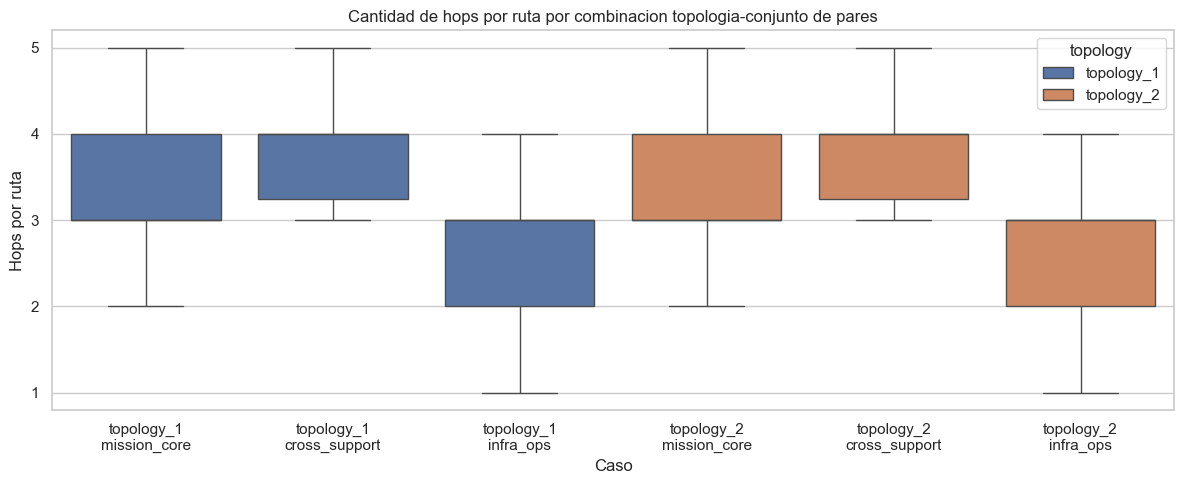

In [47]:
plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=route_stats_df,
    x="case",
    y="hops_count",
    hue="topology",
)
ax.set_title("Cantidad de hops por ruta por combinacion topologia-conjunto de pares")
ax.set_xlabel("Caso")
ax.set_ylabel("Hops por ruta")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


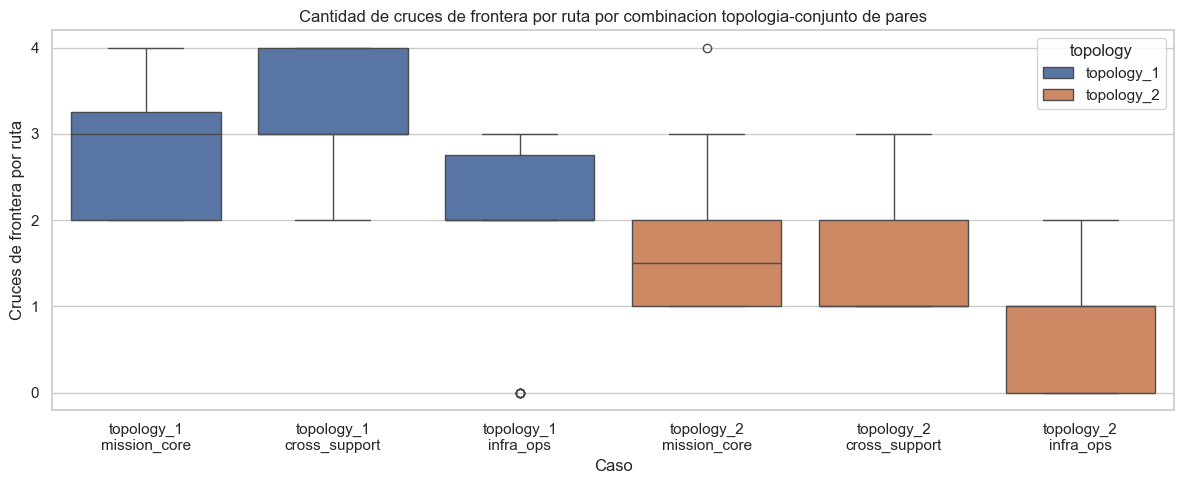

In [48]:
plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=route_stats_df,
    x="case",
    y="boundary_crossings_count",
    hue="topology",
)
ax.set_title("Cantidad de cruces de frontera por ruta por combinacion topologia-conjunto de pares")
ax.set_xlabel("Caso")
ax.set_ylabel("Cruces de frontera por ruta")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


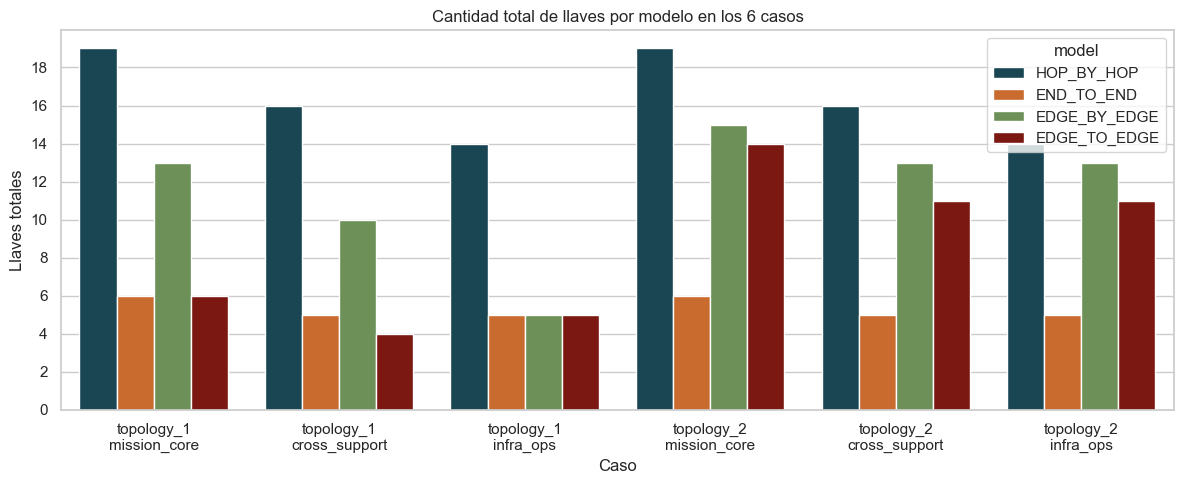

In [45]:
total_keys_df = key_summary_df[key_summary_df["key_type"] == "Total"].copy()
total_keys_df["case"] = total_keys_df["topology"] + "\n" + total_keys_df["pair_set"]
total_keys_df["count_pct"] = pct_of_max(total_keys_df["count"])


plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=total_keys_df,
    x="case",
    y="count",
    hue="model",
    palette=MODEL_PALETTE,
)
ax.set_title("Cantidad total de llaves por modelo en los 6 casos")
ax.set_xlabel("Caso")
ax.set_ylabel("Llaves totales")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Modelo 1: maximizar rutas sujeto a presupuesto de llaves

Esta seccion corre `model1_max_routes.py` para cada combinacion de topologia y conjunto de pares.


In [12]:
from models.model1_max_routes import solve_for_security_model

m1_frames = []
traces_m1 = {}
for config_name, sim_result in experiment_results.items():
    traces_m1[config_name] = {}
    for sec_model in SecurityModelType:
        sec_traces, sec_df = solve_for_security_model(sim_result, sec_model)
        sec_df = sec_df.copy()
        sec_df["config"] = config_name
        sec_df["topology"] = experiment_meta[config_name]["topology"]
        sec_df["pair_set"] = experiment_meta[config_name]["pair_set"]
        m1_frames.append(sec_df)
        traces_m1[config_name][sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))

df_m1 = pd.concat(m1_frames, ignore_index=True)
display(df_m1[df_m1['model']=="HOP_BY_HOP"])


,max_keys,selected_routes,selected_pairs,selected_keys,connectivity_pct,model,config,topology,pair_set
0,0,0,0,0,0.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
1,1,0,0,1,0.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
2,2,2,2,2,16.666667,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
3,3,6,6,3,50.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
4,4,6,6,3,50.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
...,...,...,...,...,...,...,...,...,...
237,10,23,10,10,100.000000,HOP_BY_HOP,topology_2__infra_ops,topology_2,infra_ops
238,11,26,10,11,100.000000,HOP_BY_HOP,topology_2__infra_ops,topology_2,infra_ops
239,12,28,10,12,100.000000,HOP_BY_HOP,topology_2__infra_ops,topology_2,infra_ops
240,13,28,10,13,100.000000,HOP_BY_HOP,topology_2__infra_ops,topology_2,infra_ops


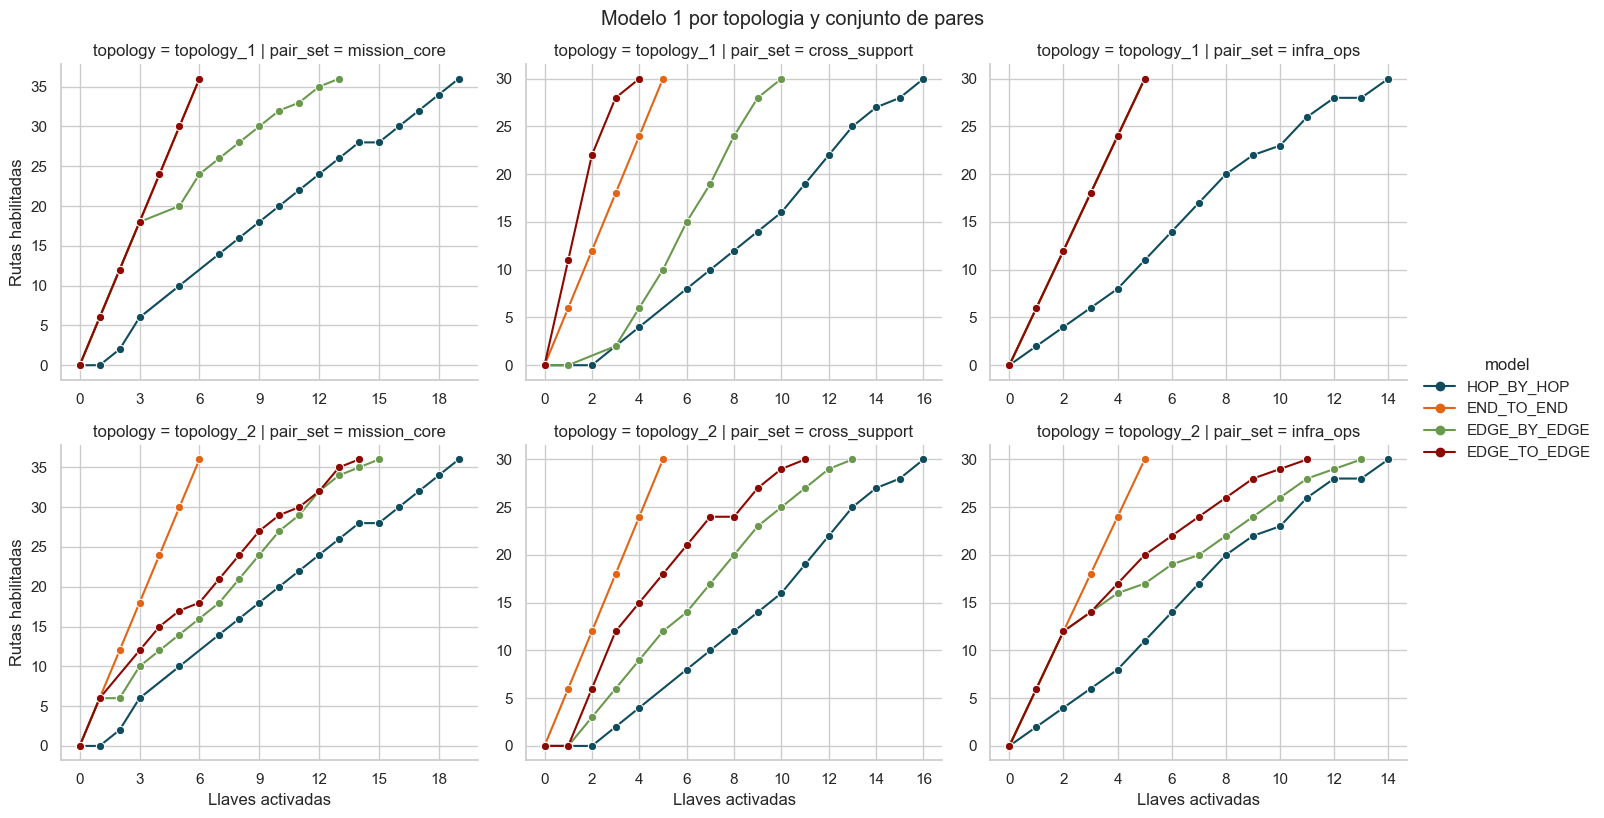

In [55]:
df_m1_plot = df_m1.copy()
df_m1_plot["selected_routes_pct"] = df_m1_plot.groupby(["topology", "pair_set"])["selected_routes"].transform(pct_of_max)

g = sns.relplot(
    data=df_m1_plot,
    kind="line",
    x="selected_keys",
    y="selected_routes",
    hue="model",
    col="pair_set",
    row="topology",
    marker="o",
    facet_kws={"sharey": False, "sharex": False},
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.2,
)
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
g.set_axis_labels("Llaves activadas", "Rutas habilitadas")
g.figure.suptitle("Modelo 1 por topologia y conjunto de pares", y=1.02)
plt.show()


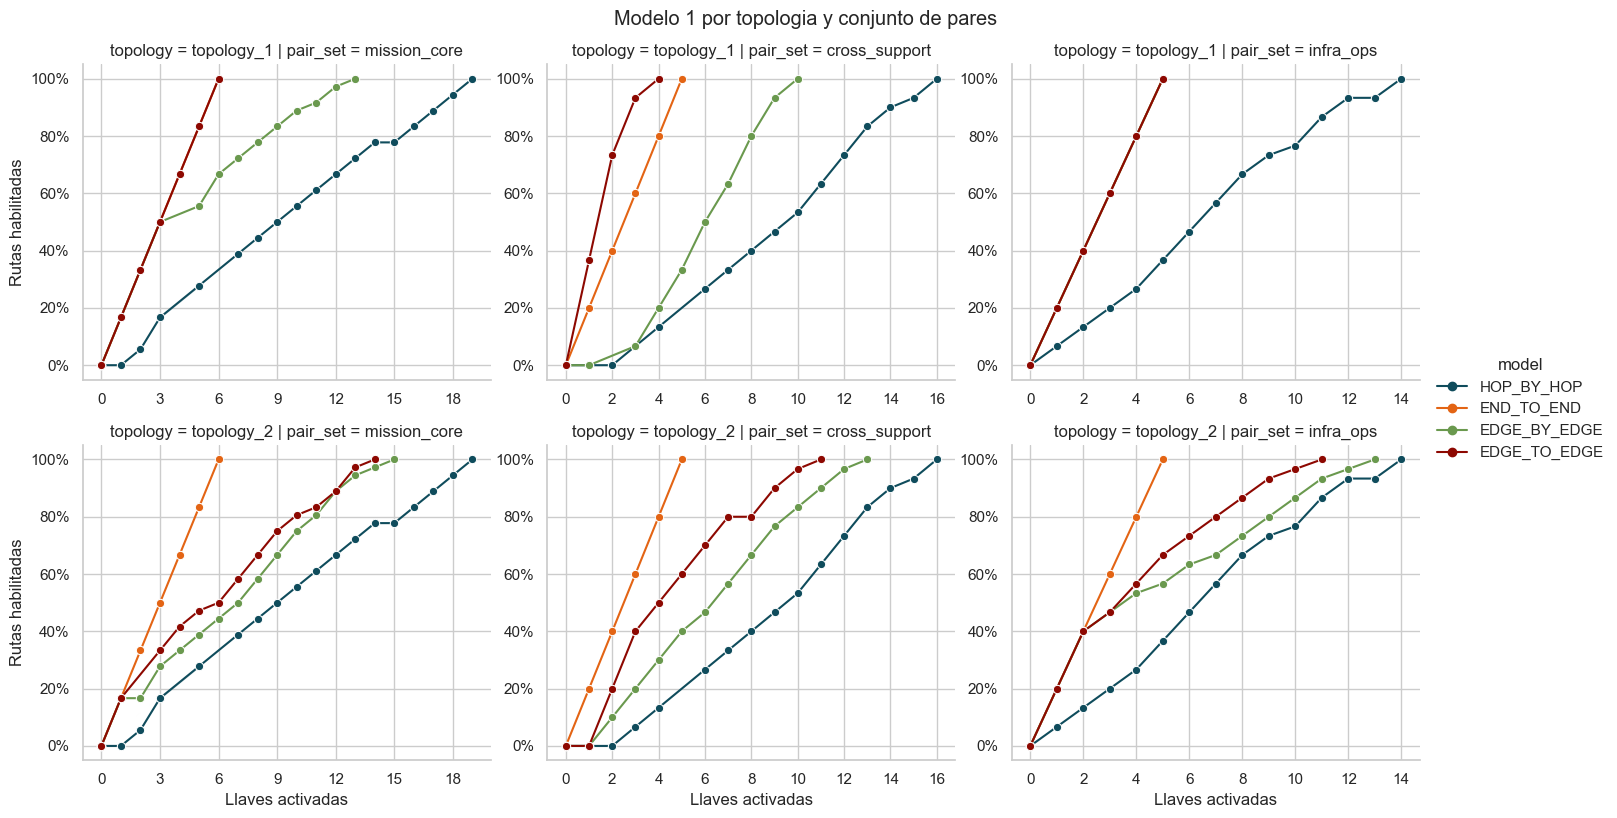

In [54]:
df_m1_plot = df_m1.copy()
df_m1_plot["selected_routes_pct"] = df_m1_plot.groupby(["topology", "pair_set"])["selected_routes"].transform(pct_of_max)

g = sns.relplot(
    data=df_m1_plot,
    kind="line",
    x="selected_keys",
    y="selected_routes_pct",
    hue="model",
    col="pair_set",
    row="topology",
    marker="o",
    facet_kws={"sharey": False, "sharex": False},
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.2,
)
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
g.set_axis_labels("Llaves activadas", "Rutas habilitadas")
apply_percent_yaxis(g)
# apply_percent_xaxis(g)
g.figure.suptitle("Modelo 1 por topologia y conjunto de pares", y=1.02)
plt.show()

## Modelo 2: minimizar llaves para un objetivo de conectividad


In [38]:
from models.model2_min_keys import solve_for_security_model as solve_m2

m2_frames = []
traces_m2 = {}
for config_name, sim_result in experiment_results.items():
    traces_m2[config_name] = {}
    for sec_model in SecurityModelType:
        sec_traces, sec_df = solve_m2(sim_result, sec_model)
        sec_df = sec_df.copy()
        sec_df["config"] = config_name
        sec_df["topology"] = experiment_meta[config_name]["topology"]
        sec_df["pair_set"] = experiment_meta[config_name]["pair_set"]
        m2_frames.append(sec_df)
        traces_m2[config_name][sec_model.name] = dict(zip(sec_df["target_connectivity_pct"], sec_traces))

df_m2 = pd.concat(m2_frames, ignore_index=True)
display(df_m2.head())


,target_connectivity_pct,required_pairs,selected_pairs,selected_routes,selected_keys,achieved_connectivity_pct,model,config,topology,pair_set
0,0,0,0,0,0,0.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
1,5,1,1,1,2,8.333333,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
2,10,2,2,2,2,16.666667,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
3,15,2,2,2,2,16.666667,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core
4,20,3,3,3,3,25.000000,HOP_BY_HOP,topology_1__mission_core,topology_1,mission_core


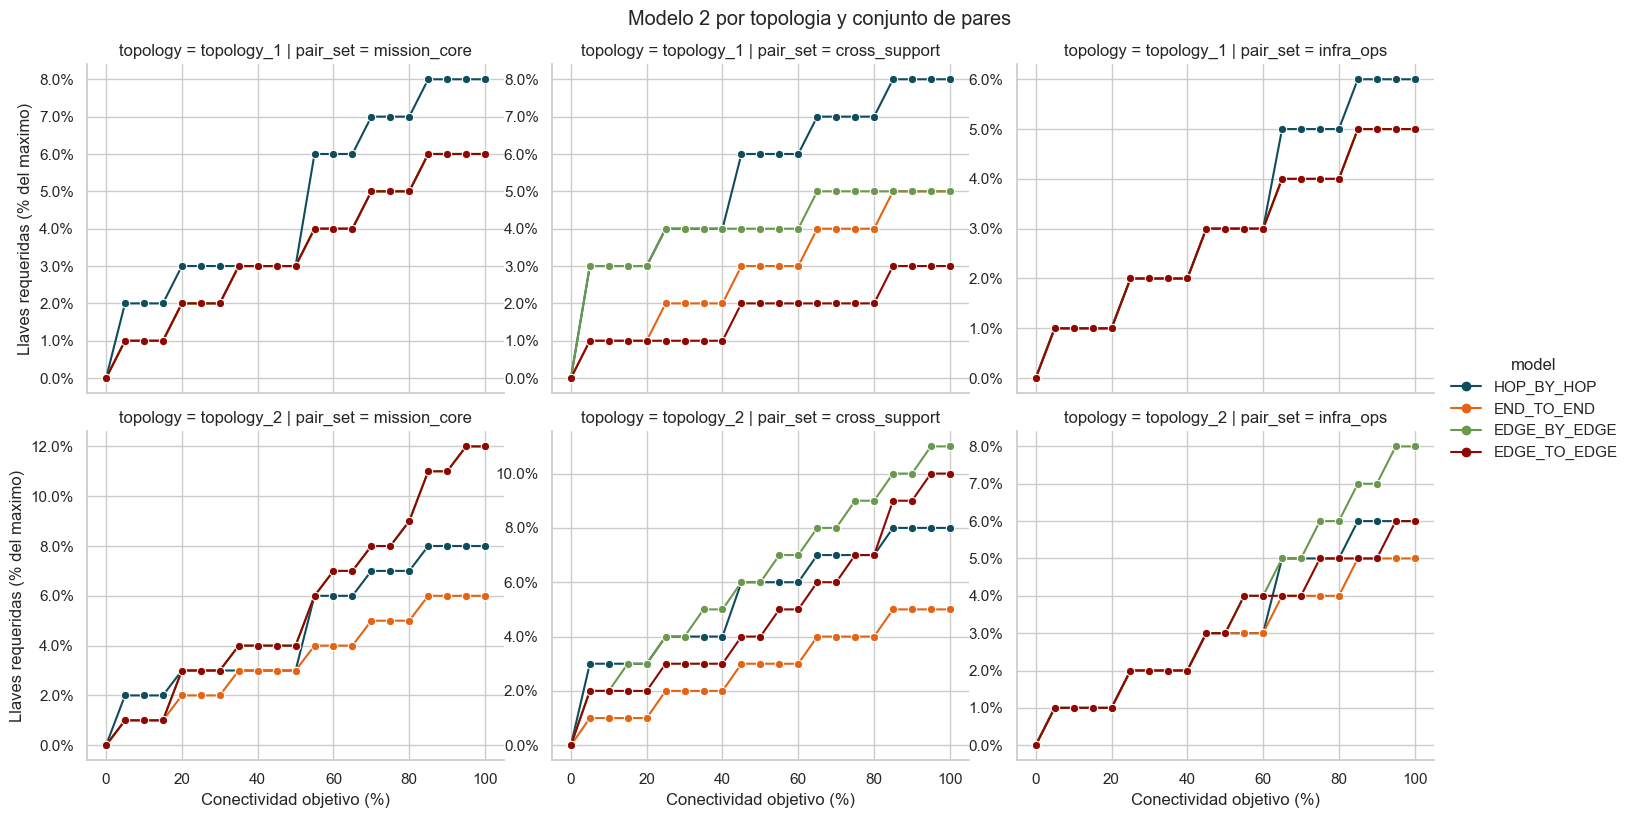

In [43]:
df_m2_plot = df_m2.copy()
df_m2_plot["selected_keys_pct"] = df_m2_plot.groupby(["topology", "pair_set"])["selected_keys"].transform(pct_of_max)

g = sns.relplot(
    data=df_m2_plot,
    kind="line",
    x="target_connectivity_pct",
    y="selected_keys",
    hue="model",
    col="pair_set",
    row="topology",
    marker="o",
    facet_kws={"sharey": False, "sharex": True},
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Conectividad objetivo (%)", "Llaves requeridas (% del maximo)")
# apply_percent_xaxis(g)
apply_percent_yaxis(g)
g.figure.suptitle("Modelo 2 por topologia y conjunto de pares", y=1.02)
plt.show()


## Modelo 4: maximizar conectividad sujeto a presupuesto de llaves

Esta variante barre presupuestos de llaves y maximiza la conectividad alcanzada del conjunto de pares. En empates, prioriza usar menos llaves y habilitar mas rutas.


In [ ]:
from models.model4_max_connectivity_under_budget import solve_for_security_model as solve_m4

m4_frames = []
traces_m4 = {}
for config_name, sim_result in experiment_results.items():
    traces_m4[config_name] = {}
    for sec_model in SecurityModelType:
        sec_traces, sec_df = solve_m4(sim_result, sec_model)
        sec_df = sec_df.copy()
        sec_df["config"] = config_name
        sec_df["topology"] = experiment_meta[config_name]["topology"]
        sec_df["pair_set"] = experiment_meta[config_name]["pair_set"]
        m4_frames.append(sec_df)
        traces_m4[config_name][sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))

df_m4 = pd.concat(m4_frames, ignore_index=True)
display(df_m4.head())


In [ ]:
g = sns.relplot(
    data=df_m4,
    kind="line",
    x="max_keys",
    y="achieved_connectivity_pct",
    hue="model",
    col="pair_set",
    row="topology",
    marker="o",
    facet_kws={"sharey": True, "sharex": False},
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Cantidad de llaves activadas", "Conectividad alcanzada (%)")
apply_percent_yaxis(g)
g.figure.suptitle("Modelo 4 por topologia y conjunto de pares", y=1.02)
plt.show()


## Modelo 3: minimizar llaves para conectividad completa del conjunto de pares


In [ ]:
from models.model3_min_keys_full_connectivity import solve_for_security_model as solve_m3

m3_frames = []
traces_m3 = {}
for config_name, sim_result in experiment_results.items():
    traces_m3[config_name] = {}
    for sec_model in SecurityModelType:
        sec_traces, sec_df = solve_m3(sim_result, sec_model)
        sec_df = sec_df.copy()
        sec_df["config"] = config_name
        sec_df["topology"] = experiment_meta[config_name]["topology"]
        sec_df["pair_set"] = experiment_meta[config_name]["pair_set"]
        m3_frames.append(sec_df)
        traces_m3[config_name][sec_model.name] = sec_traces[0] if sec_traces else None

df_m3 = pd.concat(m3_frames, ignore_index=True)
display(df_m3)


In [ ]:
plot_df = df_m3.copy()
plot_df["connectivity_label"] = plot_df["achieved_connectivity_pct"].map(lambda value: f"{value:.0f}%")
plot_df["selected_keys_pct"] = pct_of_max(plot_df["selected_keys"])
plot_df["selected_routes_pct"] = pct_of_max(plot_df["selected_routes"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=plot_df,
    x="pair_set",
    y="selected_keys_pct",
    hue="model",
    ax=axes[0],
    palette=MODEL_PALETTE,
)
axes[0].set_title("Llaves minimas para conectividad completa")
axes[0].set_xlabel("Conjunto de pares")
axes[0].set_ylabel("Llaves seleccionadas (% del maximo)")

sns.barplot(
    data=plot_df,
    x="pair_set",
    y="selected_routes_pct",
    hue="model",
    ax=axes[1],
    palette=MODEL_PALETTE,
)
axes[1].set_title("Rutas seleccionadas en la solucion optima")
axes[1].set_xlabel("Conjunto de pares")
axes[1].set_ylabel("Rutas seleccionadas (% del maximo)")

for ax in axes:
    ax.legend(title="Modelo")
apply_percent_yaxis(axes)

plt.suptitle("Modelo 3 agregado sobre ambas topologias")
plt.tight_layout()
plt.show()


## Drilldown por configuracion

Usa esta celda para inspeccionar una combinacion puntual con una tabla de pares, rutas disponibles y un heatmap de cobertura del Modelo 2.


In [ ]:
from models.model2_min_keys import plot_connectivity_pair_coverage_heatmap

FOCUS_CONFIG = "topology_2__mission_core"
FOCUS_MODEL = "EDGE_BY_EDGE"
FOCUS_CONNECTIVITY = 100.0

focus_result = experiment_results[FOCUS_CONFIG]
focus_pairs = pd.DataFrame(
    {
        "pair": [format_pair(pair) for pair in focus_result.security.pairs],
        "description": [describe_pair(pair) for pair in focus_result.security.pairs],
        "candidate_routes": [len(focus_result.routing.routes_by_pair[pair]) for pair in focus_result.security.pairs],
    }
)
display(Markdown(f"### {FOCUS_CONFIG} | {FOCUS_MODEL} | objetivo={FOCUS_CONNECTIVITY}%"))
display(focus_pairs)

trace = traces_m2[FOCUS_CONFIG][FOCUS_MODEL].get(FOCUS_CONNECTIVITY)
if trace is None:
    print("No hay solucion para esa combinacion de config/model/connectivity.")
else:
    plot_connectivity_pair_coverage_heatmap(
        traces_m2[FOCUS_CONFIG][FOCUS_MODEL],
        all_pairs=focus_result.security.pairs,
    )
    plt.show()


## Tablas resumen finales


In [ ]:
summary_m1 = (
    df_m1.groupby(["topology", "pair_set", "model"], as_index=False)
    .agg(max_selected_routes=("selected_routes", "max"), max_selected_keys=("selected_keys", "max"))
)

summary_m2 = (
    df_m2[df_m2["target_connectivity_pct"] == 100.0]
    .groupby(["topology", "pair_set", "model"], as_index=False)
    .agg(keys_for_100pct=("selected_keys", "min"), routes_for_100pct=("selected_routes", "max"))
)

summary_m3 = df_m3[[
    "topology",
    "pair_set",
    "model",
    "selected_keys",
    "selected_routes",
    "achieved_connectivity_pct",
]].copy()

summary_m4 = (
    df_m4.sort_values(
        ["topology", "pair_set", "model", "achieved_connectivity_pct", "selected_keys", "selected_routes"],
        ascending=[True, True, True, False, True, False],
    )
    .drop_duplicates(["topology", "pair_set", "model"])
    [[
        "topology",
        "pair_set",
        "model",
        "max_keys",
        "selected_keys",
        "selected_routes",
        "achieved_connectivity_pct",
    ]]
    .rename(
        columns={
            "max_keys": "budget_at_best_connectivity",
            "selected_keys": "keys_used_at_best_connectivity",
            "selected_routes": "routes_at_best_connectivity",
            "achieved_connectivity_pct": "best_connectivity_pct",
        }
    )
)

print("Modelo 1")
display(summary_m1)
print("Modelo 2 (objetivo 100%)")
display(summary_m2)
print("Modelo 3")
display(summary_m3)
print("Modelo 4")
display(summary_m4)
